## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting? 
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Emma Chung

**Date:** 9/30/2026

Q1.
1. Regression and classification are both methods used to make predictions, but they predict different types of outcomes. Regression predicts a numerical or continuous value while classification predicts a category or class. 
2. A confusion table compares the actual class of each observation with the class predicted by the model. Correct predictions appear along the diagonal of the table, while incorrect predictions appear in the other cells. It helps us see not only how often the model is correct, but also which classes the model tends to confuse with one another. This can provide more information about model performance than overall accuracy alone.
3. SSE stands for Sum of Squared Errors. It measures the total squared difference between the actual values and the values predicted by a model. A smaller SSE means that the model's predictions are generally closer to the actual values. Because the errors are squared, larger prediction errors contribute more heavily to the SSE.
4. Overfitting occurs when a model fits the training data too closely and begins capturing random noise or patterns that do not generalize to new data. Underfitting occurs when a model is too simple to capture the important patterns in the data. 
5. Splitting the data into training and testing sets lets us train the model on one set of data and see how well it works on new data. We can try different values of k and choose the one that gives the best accuracy or lowest SSE on the test set. This helps us choose a model that performs well on data it has not seen before.
6. A class label gives one clear prediction, which makes it easy to understand. However, it does not show how confident the model is in that prediction. A probability distribution gives the probability of each possible class, so it shows the model's uncertainty. However, it can be more difficult to interpret than a single class label.

Q2.

In [26]:
import pandas as pd

df = pd.read_csv("data/land_mines.csv")

df.head()

,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


In [27]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   voltage    338 non-null    float64
 1   height     338 non-null    float64
 2   soil       338 non-null    float64
 3   mine_type  338 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 10.7 KB


,voltage,height,soil,mine_type
count,338.000000,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550,2.952663
std,0.195819,0.306043,0.344244,1.419703
min,0.197734,0.000000,0.000000,1.000000
25%,0.309737,0.272727,0.200000,2.000000
50%,0.359516,0.545455,0.600000,3.000000
75%,0.482628,0.727273,0.800000,4.000000
max,0.999999,1.000000,1.000000,5.000000


In [28]:
df["mine_type"].value_counts().sort_index()

mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64

In [29]:
df.groupby("mine_type")[["voltage", "height", "soil"]].mean()

,voltage,height,soil
mine_type,,,
1,0.296463,0.495519,0.492958
2,0.721123,0.487013,0.508571
3,0.402408,0.527548,0.496970
4,0.345365,0.506887,0.503030
5,0.379598,0.530070,0.516923


In [30]:
df.isnull().sum()

voltage      0
height       0
soil         0
mine_type    0
dtype: int64

1. The dataset contains 338 observations. The three features are voltage, height, and soil, while mine_type is the target variable with classes ranging from 1 to 5. Voltage ranges from about 0.198 to 1, while height and soil both range from 0 to 1. There are no missing values in these columns. The mine types are also fairly evenly distributed, with 71 observations of Type 1, 70 of Type 2, 66 each of Types 3 and 4, and 65 of Type 5.

In [31]:
from sklearn.model_selection import train_test_split

X = df[["voltage", "height", "soil"]]
y = df["mine_type"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.5,
    random_state=42,
    stratify=y
)

print("Training set:", len(X_train))
print("Test set:", len(X_test))

Training set: 169
Test set: 169


2. I split the data evenly into training and testing sets, using 50% of the observations for each. I stratified by mine type so that the different mine classes remained approximately evenly represented in both sets.

In [32]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [33]:
accuracies = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    accuracies.append(accuracy)
    print(f"k = {k}: Accuracy = {accuracy:.3f}")

k = 1: Accuracy = 0.402
k = 2: Accuracy = 0.438
k = 3: Accuracy = 0.379
k = 4: Accuracy = 0.355
k = 5: Accuracy = 0.314
k = 6: Accuracy = 0.325
k = 7: Accuracy = 0.314
k = 8: Accuracy = 0.308
k = 9: Accuracy = 0.349
k = 10: Accuracy = 0.337
k = 11: Accuracy = 0.355
k = 12: Accuracy = 0.337
k = 13: Accuracy = 0.349
k = 14: Accuracy = 0.314
k = 15: Accuracy = 0.331
k = 16: Accuracy = 0.343
k = 17: Accuracy = 0.361
k = 18: Accuracy = 0.337
k = 19: Accuracy = 0.337
k = 20: Accuracy = 0.343


In [34]:
best_k = accuracies.index(max(accuracies)) + 1

print("Best k:", best_k)
print("Best accuracy:", max(accuracies))

Best k: 2
Best accuracy: 0.4378698224852071


3. I built a k-nearest neighbors classifier and tested values of k from 1 to 20. For each value, I trained the model on the training data and calculated its accuracy on the test data. I selected k = 2 because it had the highest test accuracy of about 43.8%.

In [35]:
knn = KNeighborsClassifier(n_neighbors=2)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

In [36]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

confusion_table = pd.DataFrame(
    cm,
    index=["Actual 1", "Actual 2", "Actual 3", "Actual 4", "Actual 5"],
    columns=["Predicted 1", "Predicted 2", "Predicted 3", "Predicted 4", "Predicted 5"]
)

confusion_table

,Predicted 1,Predicted 2,Predicted 3,Predicted 4,Predicted 5
Actual 1,25,0,6,4,1
Actual 2,0,32,0,3,0
Actual 3,12,2,9,6,4
Actual 4,12,5,8,8,0
Actual 5,15,2,10,5,0


4. The optimal model had an overall accuracy of about 43.8%. The model performed best for mine types 1 and 2. It correctly classified 25 of 36 Type 1 mines and 32 of 35 Type 2 mines. Performance was worse for Types 3 and 4, with only 9 of 33 Type 3 mines and 8 of 33 Type 4 mines correctly classified. The model performed worst for Type 5, where none of the 32 observations were correctly classified. Type 5 mines were most often incorrectly predicted as Type 1 or Type 3.

5. I would not recommend using this model by itself to identify a mine because it makes a large number of classification errors. In particular, it fails to correctly identify any Type 5 mines in the test set. The model could be used as an additional source of information, but its predictions should be confirmed using other methods before someone makes a decision. This is especially important in a situation involving land mines, where an incorrect prediction could have serious consequences.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 046c1b4aa386952a8483244fbf9cb44b241bcefb
- **AI tool and model used:** chat GPT, GPT 5.6 Sol

### *Prompts used


1. Can you look over my answer for regression vs. classification? Is there anything I should change or clarify?

2. Does my explanation of a confusion table fully answer the question about model performance?

3. I said that SSE measures the squared differences between actual and predicted values. Is that enough, or am I missing something important?

4. Can you review how I explained overfitting and underfitting and make sure I have the difference right?

5. Does my answer about splitting the data into training and testing sets make sense? I want to keep this explanation pretty simple.

6. Look over my answer about class labels versus probability distributions. Is there anything I should add about the strengths and weaknesses of each?

7. Here is the EDA I did for the land mines dataset. Do these summary statistics and class counts cover what the question is asking for?

8. I used a 50/50 train-test split and stratified by mine_type. Is this a good way to split this dataset?

9. For my k-NN model, I tested k values from 1 to 20 and chose the one with the highest test accuracy. Can you check if this is a reasonable way to select k?

10. My best model was k = 2 with an accuracy of about 43.8%. Can you help me check my interpretation of the confusion table and point out which mine types the model does better or worse on?

11. Based on the errors in my confusion table, does my explanation of how this model should actually be used make sense? Is there anything important I should mention?

### *AI-proposed changes



1. Clarify that regression predicts numerical values, while classification predicts categories or class labels.

2. Add that a confusion table is useful because it shows which specific classes the model tends to confuse, rather than only showing overall accuracy.

3. Mention that a lower SSE generally means the model's predictions are closer to the actual values and that squaring the errors gives more weight to larger errors.

4. Connect overfitting and underfitting to k-NN by explaining that a very small k can lead to overfitting, while a very large k can lead to underfitting.

5. Make the training/test explanation more direct by emphasizing that the test data allows the model to be evaluated on observations it has not already seen.

6. Add that probability distributions show uncertainty between possible classes, while a single class label is simpler but hides this information.

7. In the EDA, include the number of observations in each mine type and note that the classes are fairly balanced. Do not interpret the mean of `mine_type` because the numbers represent categories.

8. Use a stratified 50/50 split so that the five mine types remain approximately balanced between the training and test sets.

9. Compare several values of k and select the one with the best test accuracy. Based on the results, use k = 2 because it had the highest accuracy of about 43.8%.

10. Do not rely only on the overall accuracy when evaluating the final model. Use the confusion table to explain that the model performs much better for Types 1 and 2 than Types 3, 4, and 5, and point out that it did not correctly classify any Type 5 observations.

11. Emphasize that this model should not be used as the only method for identifying a land mine because its overall accuracy is low and its errors are not evenly distributed across the five mine types.

### *Evaluation of AI suggestions


| **Change** | **Decision** | **Reason and verification** |
| ---------- | ------------ | --------------------------- |
| 1 | Accept | My original answer was correct, but this made the difference between regression and classification clearer. |
| 2 | Accept | This added an important point about the confusion table showing which classes are being confused, not just overall accuracy. |
| 3 | Accept | My explanation of SSE was correct, but mentioning that larger errors have more influence because they are squared made it more complete. |
| 4 | Accept | I already explained overfitting and underfitting, but connecting them specifically to small and large values of k made the answer more relevant to this assignment. |
| 5 | Accept | This simplified my explanation and made it clearer that the purpose of the test set is to evaluate the model on data it has not already seen. |
| 6 | Accept | My original answer covered the main difference, but adding uncertainty made the advantage of probability distributions clearer. |
| 7 | Accept | I verified the class counts with `value_counts()`. The classes were fairly balanced, and I agreed that the mean of `mine_type` was not useful because it represents categories. |
| 8 | Accept | I used `stratify=y` and verified that the training and test sets kept the mine types approximately balanced. |
| 9 | Modify | I agreed with comparing multiple values of k, and my results showed that k = 2 had the highest accuracy at about 43.8%. I kept the test-set approach because that is what the assignment asks us to use. |
| 10 | Accept | I checked the suggestion against my confusion table. Types 1 and 2 had the strongest performance, while Types 3 and 4 were less accurate and no Type 5 observations were correctly classified. |
| 11 | Accept | The suggestion matched the results. Since the model only had about 43.8% accuracy and completely missed Type 5, it would not be appropriate to rely on it alone. |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

## Q1

### 1. What is the difference between regression and classification?

Regression predicts a numerical or continuous value, while classification predicts a category or class. For example, predicting a house price would be regression, while predicting a mine type would be classification.

### 2. What is a confusion table? What does it help us understand about a model's performance?

A confusion table compares the actual classes to the classes predicted by the model. Correct predictions appear along the diagonal, while the other cells show incorrect predictions. It helps us see which classes the model predicts well and which classes it tends to confuse.

### 3. What does the SSE quantify about a particular model?

SSE stands for Sum of Squared Errors. It measures the total squared difference between the actual and predicted values. A lower SSE means the predictions are generally closer to the actual values. Squaring the errors also causes larger errors to have a greater effect on the SSE.

### 4. What are overfitting and underfitting?

Overfitting happens when a model fits the training data too closely and does not perform as well on new data. Underfitting happens when a model is too simple to capture important patterns in the data. In k-NN, a very small k can lead to overfitting, while a very large k can lead to underfitting.

### 5. Why does splitting the data into training and testing sets, and choosing k by evaluating accuracy or SSE on the test set, improve model performance?

Splitting the data into training and testing sets lets us train the model on one set of data and see how well it works on new data. We can try different values of k and choose the one that gives the best accuracy or lowest SSE on the test set. This helps us choose a model that performs well on data it has not seen before.

### 6. Class label vs. probability distribution

A class label gives one clear prediction, which makes it simple and easy to understand. However, it does not show how confident the model is in that prediction. A probability distribution gives the probability of each possible class, so it shows the model's uncertainty. However, it can be more difficult to interpret than a single class label.


### Q2.1: Exploratory Data Analysis

First, I loaded the land mines dataset and examined the first few rows, summary statistics, class distribution, and missing values.

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   voltage    338 non-null    float64
 1   height     338 non-null    float64
 2   soil       338 non-null    float64
 3   mine_type  338 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 10.7 KB


In [38]:
df.describe()

,voltage,height,soil,mine_type
count,338.000000,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550,2.952663
std,0.195819,0.306043,0.344244,1.419703
min,0.197734,0.000000,0.000000,1.000000
25%,0.309737,0.272727,0.200000,2.000000
50%,0.359516,0.545455,0.600000,3.000000
75%,0.482628,0.727273,0.800000,4.000000
max,0.999999,1.000000,1.000000,5.000000


The dataset contains 338 observations. The three features are `voltage`, `height`, and `soil`, while `mine_type` is the target variable with classes ranging from 1 to 5. Voltage ranges from about 0.198 to 1, while height and soil both range from 0 to 1. There are no missing values in these columns.

The mine types are fairly evenly distributed, with 71 observations of Type 1, 70 of Type 2, 66 of Type 3, 66 of Type 4, and 65 of Type 5. Since `mine_type` represents categories, its numerical mean is not particularly meaningful.

### Q2.2: Training and Testing Split

I split the data into 50% training data and 50% testing data. I used stratification so that the five mine types remained approximately evenly represented in both sets.

In [39]:
from sklearn.model_selection import train_test_split

X = df[["voltage", "height", "soil"]]
y = df["mine_type"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.5,
    random_state=42,
    stratify=y
)

print("Training set:", len(X_train))
print("Test set:", len(X_test))

Training set: 169
Test set: 169


This resulted in 169 observations in the training set and 169 observations in the test set.

### Q2.3: k-Nearest Neighbors Model

To choose a value for k, I tested values from 1 to 20. For each value of k, I trained a k-nearest neighbors classifier using the training data and calculated its accuracy on the test data.

In [40]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

accuracies = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    accuracies.append(accuracy)

    print(f"k = {k}: Accuracy = {accuracy:.3f}")

k = 1: Accuracy = 0.402
k = 2: Accuracy = 0.438
k = 3: Accuracy = 0.379
k = 4: Accuracy = 0.355
k = 5: Accuracy = 0.314
k = 6: Accuracy = 0.325
k = 7: Accuracy = 0.314
k = 8: Accuracy = 0.308
k = 9: Accuracy = 0.349
k = 10: Accuracy = 0.337
k = 11: Accuracy = 0.355
k = 12: Accuracy = 0.337
k = 13: Accuracy = 0.349
k = 14: Accuracy = 0.314
k = 15: Accuracy = 0.331
k = 16: Accuracy = 0.343
k = 17: Accuracy = 0.361
k = 18: Accuracy = 0.337
k = 19: Accuracy = 0.337
k = 20: Accuracy = 0.343


In [41]:
best_k = accuracies.index(max(accuracies)) + 1

print("Best k:", best_k)
print("Best accuracy:", max(accuracies))

Best k: 2
Best accuracy: 0.4378698224852071


The best value was k = 2, which produced the highest test accuracy of approximately 43.8%. Therefore, I selected k = 2 for the final model.

I also plotted the accuracy for each value of k to see how the model's performance changed as k increased.

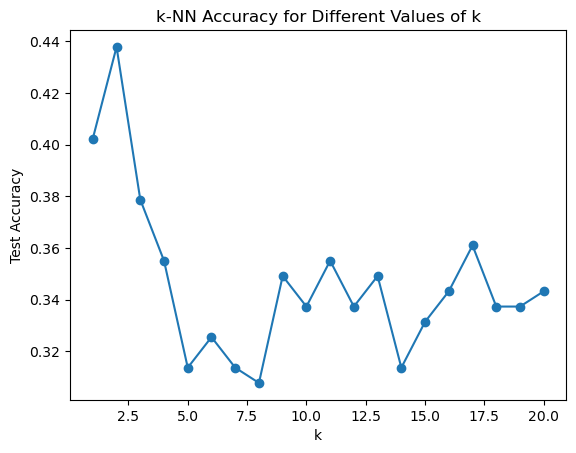

In [42]:
import matplotlib.pyplot as plt

plt.plot(range(1, 21), accuracies, marker="o")
plt.xlabel("k")
plt.ylabel("Test Accuracy")
plt.title("k-NN Accuracy for Different Values of k")
plt.show()

### Q2.4: Confusion Table and Model Performance

Using the selected value of k = 2, I trained the final model and used it to predict the mine types in the test set.

In [43]:
knn = KNeighborsClassifier(n_neighbors=2)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

In [44]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.4378698224852071


I then created a confusion table to compare the actual mine types with the mine types predicted by the model.

In [45]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

confusion_table = pd.DataFrame(
    cm,
    index=["Actual 1", "Actual 2", "Actual 3", "Actual 4", "Actual 5"],
    columns=[
        "Predicted 1",
        "Predicted 2",
        "Predicted 3",
        "Predicted 4",
        "Predicted 5"
    ]
)

confusion_table

,Predicted 1,Predicted 2,Predicted 3,Predicted 4,Predicted 5
Actual 1,25,0,6,4,1
Actual 2,0,32,0,3,0
Actual 3,12,2,9,6,4
Actual 4,12,5,8,8,0
Actual 5,15,2,10,5,0


The optimal model had an overall accuracy of about 43.8%. The model performed best for mine Types 1 and 2. It correctly classified 25 of 36 Type 1 mines and 32 of 35 Type 2 mines.

Performance was worse for Types 3 and 4, with only 9 of 33 Type 3 mines and 8 of 33 Type 4 mines correctly classified. The model performed worst for Type 5, where none of the 32 observations were correctly classified. Type 5 mines were most often incorrectly predicted as Type 1 or Type 3.

This shows that overall accuracy does not tell the entire story. The confusion table shows that the model performs much better for some mine types than others.

### Q2.5: Practical Use of the Model

I would not recommend using this model by itself to identify a mine because it makes a large number of classification errors. In particular, it fails to correctly identify any Type 5 mines in the test set.

The model could be used as an additional source of information, but its predictions should be confirmed using other methods before making a decision. This is especially important in a situation involving land mines, where an incorrect prediction could have serious consequences.

### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

### Reflection

Using AI was helpful because it allowed me to check my original work and see where my answers could be clearer or more complete. Most of my original answers were correct, so I mainly used AI to review my explanations and suggest details that I may have left out. For example, it helped me better explain how a confusion table gives more information than overall accuracy and how different values of k can relate to overfitting and underfitting.

For the coding portion, AI helped me review my approach and interpret the results of my k-NN model. I still checked the suggestions against the output from my own code before accepting them. One of the biggest things I noticed was that even though the model had an overall accuracy of about 43.8%, that number did not fully explain how the model was performing. Looking at the confusion table showed that the model did fairly well with Types 1 and 2 but did not correctly classify any Type 5 observations.